In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [2]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
import os

2026-03-19 22:29:04.428855: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1773959344.631110      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1773959344.687245      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1773959345.127647      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773959345.127687      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773959345.127691      55 computation_placer.cc:177] computation placer alr

In [3]:
d = 3 #hilbert space dimensions

input_dim = d**2
output_dim = d**2
save_dir = f'/kaggle/working/dataset_d{d}'

X_train =np.load(os.path.join(save_dir, "X_train.npy"))
Y_train =np.load(os.path.join(save_dir, "Y_train.npy"))
X_val=np.load(os.path.join(save_dir, "X_val.npy"))
Y_val=np.load(os.path.join(save_dir, "Y_val.npy"))
X_test=np.load(os.path.join(save_dir, "X_test.npy"))
Y_test=np.load(os.path.join(save_dir, "Y_test.npy"))

**Gamma Error**

In [4]:
import numpy as np

# ----------------------------------------------------------------------
# Adversarial corruption operating on frequency vectors
# (compatible with your dataset where X = probability/frequency vectors)
# ----------------------------------------------------------------------

def freq_to_outcomes(freq_vec, n_trials=10000):
    """
    Convert a frequency vector back to discrete outcomes by multinomial sampling.
    This simulates having n_trials single-copy measurements.
    freq_vec: shape (N,) – probability vector over N POVM outcomes
    Returns: array of shape (n_trials,) with integer outcome indices
    """
    # Ensure valid probability vector (normalise for numerical safety)
    p = np.array(freq_vec, dtype=np.float64)
    p = np.clip(p, 0, None)
    p /= p.sum()
    outcomes = np.random.choice(len(p), size=n_trials, p=p)
    return outcomes


def corrupt_outcomes(outcomes, gamma, n_povm_outcomes, strategy='worst_case'):
    """
    Corrupt exactly floor(gamma * n) outcomes, as per Definition 1.2 of the paper.
    
    outcomes:         array of shape (n,) with integer outcome indices
    gamma:            corruption fraction (hard constraint, not probabilistic)
    n_povm_outcomes:  total number of POVM outcomes (N = d^2)
    strategy:
      'worst_case' – adversary always picks outcome 0 (maximum bias toward one outcome)
      'random'     – adversary picks a uniformly random outcome (weaker, non-strategic)
      'targeted'   – adversary picks the outcome least likely under the true distribution
                     (requires knowing the freq vector; strongest practical attack)
    """
    n = len(outcomes)
    corrupted = outcomes.copy()

    # Hard constraint: corrupt EXACTLY floor(gamma * n) outcomes (not probabilistic)
    n_corrupt = int(np.floor(gamma * n))
    if n_corrupt == 0:
        return corrupted

    # Adversary selects which indices to corrupt
    # (worst-case adversary would pick optimally; here we use random index selection
    #  as a practical approximation – the damage comes from the replacement value)
    corrupt_indices = np.random.choice(n, size=n_corrupt, replace=False)

    if strategy == 'worst_case':
        # Always replace with outcome 0 → maximally biases frequency vector
        corrupted[corrupt_indices] = 0

    elif strategy == 'random':
        # Replace with a uniformly random outcome (weakest adversary)
        corrupted[corrupt_indices] = np.random.randint(
            0, n_povm_outcomes, size=n_corrupt
        )

    elif strategy == 'targeted':
        # Replace with the least probable outcome under the true distribution
        # This is the most damaging: it moves probability mass to an unexpected bin
        least_likely = np.argmin(
            np.bincount(outcomes, minlength=n_povm_outcomes)
        )
        corrupted[corrupt_indices] = least_likely

    return corrupted


def outcomes_to_freq(outcomes, n_povm_outcomes):
    """
    Convert discrete outcomes back to a normalised frequency vector.
    outcomes:         array of shape (n,)
    n_povm_outcomes:  N = d^2
    Returns: normalised frequency vector of shape (N,)
    """
    counts = np.bincount(outcomes, minlength=n_povm_outcomes)
    return (counts / len(outcomes)).astype(np.float32)


def corrupt_freq_vector(freq_vec, gamma, n_povm_outcomes,
                        strategy='worst_case', n_trials=10000):
    """
    Full pipeline: freq vector → outcomes → corrupt → freq vector.
    This is what you apply to each row of X_test.

    freq_vec:         shape (N,) – one row of X_test
    gamma:            corruption fraction
    n_povm_outcomes:  N = d^2
    strategy:         'worst_case', 'random', or 'targeted'
    n_trials:         number of simulated single-copy measurements
    """
    outcomes          = freq_to_outcomes(freq_vec, n_trials=n_trials)
    corrupted_outcomes = corrupt_outcomes(outcomes, gamma, n_povm_outcomes, strategy)
    return outcomes_to_freq(corrupted_outcomes, n_povm_outcomes)


def corrupt_dataset(X, gamma, n_povm_outcomes,
                    strategy='worst_case', n_trials=10000):
    """
    Apply adversarial corruption to every sample in X.
    X:                shape (n_samples, N)
    Returns X_corr:   shape (n_samples, N)
    """
    X_corr = np.zeros_like(X)
    for i in range(len(X)):
        X_corr[i] = corrupt_freq_vector(
            X[i], gamma, n_povm_outcomes, strategy, n_trials
        )
    return X_corr


# ----------------------------------------------------------------------
# Usage with your generated dataset
# ----------------------------------------------------------------------

# Load your test set (already in memory if running in same session)
# X_test shape: (1000, 9)  for d=3, N=d^2=9
# Y_test shape: (1000, 9)

d               = 3
N               = d**2          # 9 POVM outcomes
gamma           = 0.1           # 10% corruption
n_trials        = 10_000        # single-copy measurements per state

print("Applying adversarial corruption to test set...")
print(f"  gamma={gamma}, strategy comparisons: worst_case / random / targeted")
print(f"  n_trials per sample: {n_trials}")

X_test_worst    = corrupt_dataset(X_test, gamma, N, strategy='worst_case',  n_trials=n_trials)
X_test_random   = corrupt_dataset(X_test, gamma, N, strategy='random',      n_trials=n_trials)
X_test_targeted = corrupt_dataset(X_test, gamma, N, strategy='targeted',    n_trials=n_trials)

print(f"Clean    X_test shape:     {X_test.shape}")
print(f"Corrupted (worst_case):    {X_test_worst.shape}")
print(f"Corrupted (random):        {X_test_random.shape}")
print(f"Corrupted (targeted):      {X_test_targeted.shape}")

# Quick sanity check: frequency vectors should still sum to ~1
print(f"\nSanity check (row sums should be 1.0):")
print(f"  Clean:       {X_test.sum(axis=1)[:5].round(4)}")
print(f"  Worst-case:  {X_test_worst.sum(axis=1)[:5].round(4)}")
print(f"  Random:      {X_test_random.sum(axis=1)[:5].round(4)}")
print(f"  Targeted:    {X_test_targeted.sum(axis=1)[:5].round(4)}")

# ----------------------------------------------------------------------
# Evaluate your trained model on corrupted inputs
# (assumes model is already trained and loaded)
# ----------------------------------------------------------------------

# from tensorflow.keras.models import load_model
# model = load_model(f"best_model_d{d}.keras")

# Y_pred_clean    = model.predict(X_test,         verbose=0)
# Y_pred_worst    = model.predict(X_test_worst,   verbose=0)
# Y_pred_random   = model.predict(X_test_random,  verbose=0)
# Y_pred_targeted = model.predict(X_test_targeted,verbose=0)

# Then compute Hilbert-Schmidt distances to compare degradation across strategies

Applying adversarial corruption to test set...
  gamma=0.1, strategy comparisons: worst_case / random / targeted
  n_trials per sample: 10000
Clean    X_test shape:     (1000, 9)
Corrupted (worst_case):    (1000, 9)
Corrupted (random):        (1000, 9)
Corrupted (targeted):      (1000, 9)

Sanity check (row sums should be 1.0):
  Clean:       [1. 1. 1. 1. 1.]
  Worst-case:  [1. 1. 1. 1. 1.]
  Random:      [1. 1. 1. 1. 1.]
  Targeted:    [1. 1. 1. 1. 1.]


In [5]:
d = 3 #hilbert space dimensions

input_dim = d**2
output_dim = d**2

model =  models.Sequential(name=f"QST{d}")

model.add(layers.InputLayer(input_shape = (input_dim,)))

model.add(layers.Dense(200,activation ='relu'))
model.add(layers.Dense(180,activation ='relu'))
model.add(layers.Dense(180,activation ='relu'))
model.add(layers.Dense(160,activation ='relu'))
model.add(layers.Dense(160,activation ='relu'))
model.add(layers.Dense(160,activation ='relu'))
model.add(layers.Dense(160,activation ='relu'))
model.add(layers.Dense(200,activation ='relu'))

model.add(layers.Dense(output_dim, activation = 'tanh'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(
2026-03-19 22:30:08.756069: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [6]:
optimizer = tf.keras.optimizers.Nadam(
    learning_rate = 0.001,
    beta_1 = 0.9,
    beta_2 = 0.999,
    epsilon = 1e-7
)

model.compile(optimizer=optimizer,
             loss='mse',
             metrics=['mae'])

model.summary()

Model: "QST3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 200)            │         2,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 180)            │        36,180 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 180)            │        32,580 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 160)            │        28,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 160)            │        25,760 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 160)            │        25,760 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 160)            │        25,760 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 200)            │        32,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 9)              │         1,809 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 211,009 (824.25 KB)

 Trainable params: 211,009 (824.25 KB)

 Non-trainable params: 0 (0.00 B)

In [7]:
early_stop= callbacks.EarlyStopping(
    monitor='val_loss',
    patience = 200,
    restore_best_weights= True,

    verbose=2
)


checkpoint = callbacks.ModelCheckpoint(
    filepath = f"best_moodel_d{d}.keras",
    monitor = 'vals_loss',
    save_best_only = True,
    verbose = 1
)

history = model.fit(
    X_train, Y_train,
    batch_size = 100,
    epochs = 2000,
    validation_data = (X_val, Y_val),
    callbacks = [early_stop, checkpoint],
    verbose = 1
)

test_loss, test_mae  = model.evaluate(X_test, Y_test, verbose = 0)

print(f"nTest loss (MSE): {test_loss:.6f}")
print(f"Test MAE: {test_mae:.6f}")

model.save(f"final_model_d{d}.keras")

Epoch 1/2000
80/80 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - loss: 0.0544 - mae: 0.1822 - val_loss: 0.0226 - val_mae: 0.1177
Epoch 2/2000
10/80 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0218 - mae: 0.1145 

/usr/local/lib/python3.12/dist-packages/keras/src/callbacks/model_checkpoint.py:302: UserWarning: Can save best model only with vals_loss available.
  if self._should_save_model(epoch, batch, logs, filepath):


80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0198 - mae: 0.1085 - val_loss: 0.0148 - val_mae: 0.0907
Epoch 3/2000
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0139 - mae: 0.0883 - val_loss: 0.0112 - val_mae: 0.0764
Epoch 4/2000
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0109 - mae: 0.0746 - val_loss: 0.0099 - val_mae: 0.0693
Epoch 5/2000
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0089 - mae: 0.0654 - val_loss: 0.0099 - val_mae: 0.0729
Epoch 6/2000
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0085 - mae: 0.0633 - val_loss: 0.0081 - val_mae: 0.0602
Epoch 7/2000
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0081 - mae: 0.0624 - val_loss: 0.0074 - val_mae: 0.0583
Epoch 8/2000
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0074 - mae: 0.0590 - val_loss: 0.0064 - val_mae: 0.0542
Epoch 9/2000
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0069 - mae: 0.0559 - val_loss: 0.0056 - val_mae: 0.0505
Epoch 10/2000
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0061 -

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
Trace distance  –  mean: 0.0276   std: 0.0113   max: 0.1423
HS distance     –  mean: 0.0366   std: 0.0152   max: 0.2006
Metrics recorded: ['loss', 'mae', 'val_loss', 'val_mae']


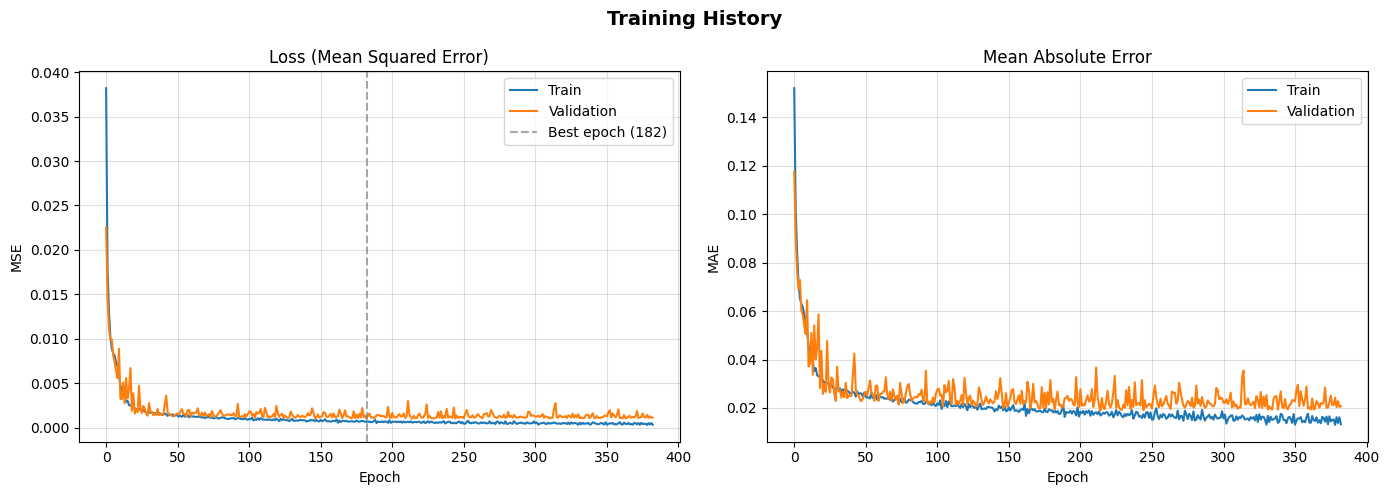

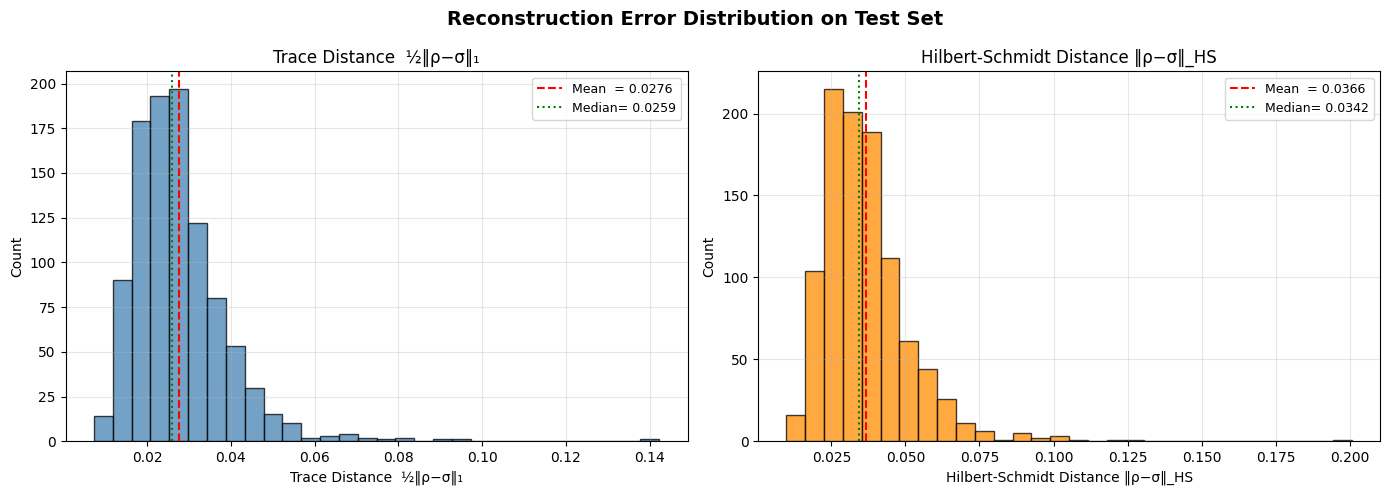

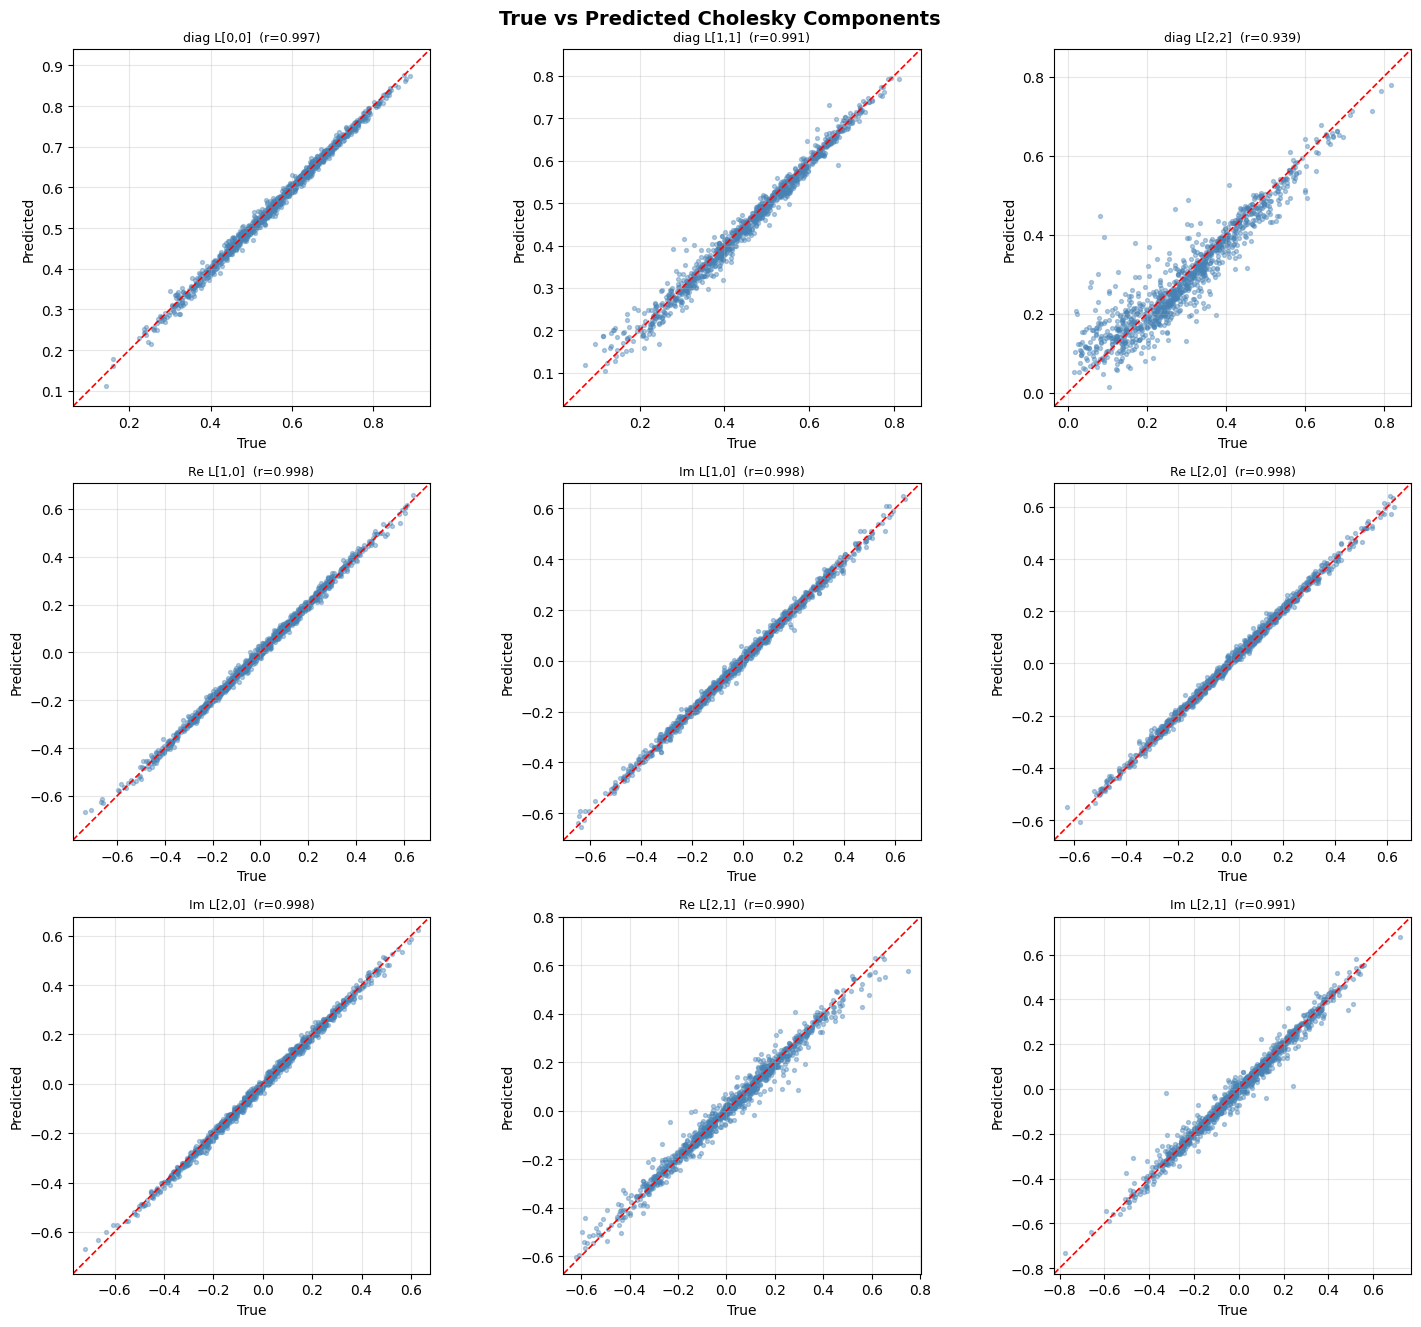

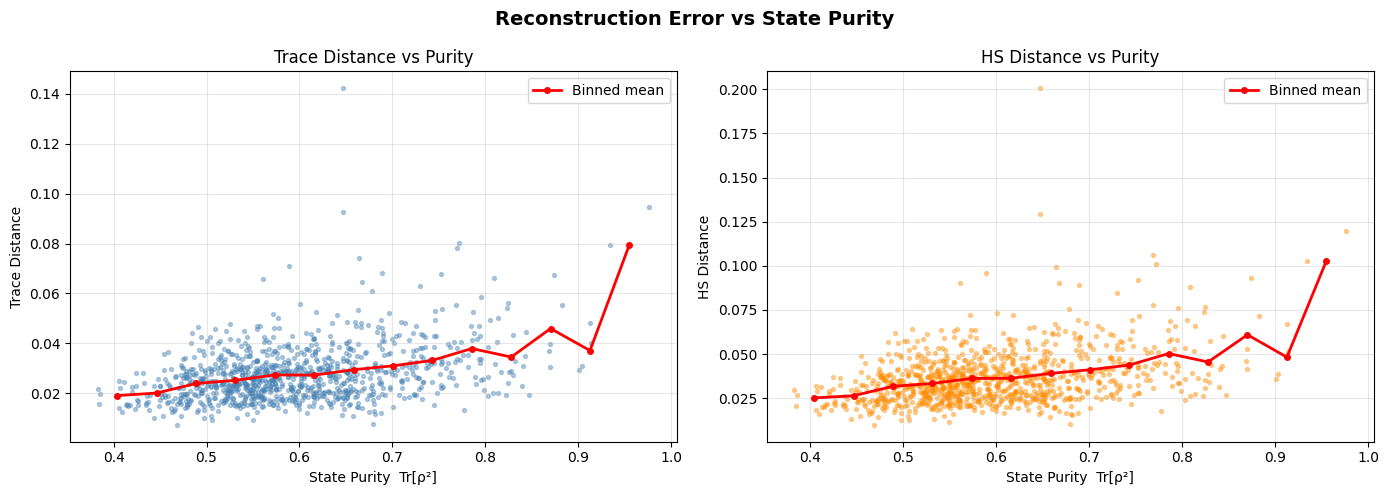

In [11]:
Y_pred = model.predict(X_test)

import numpy as np
import matplotlib.pyplot as plt

# ── 0. Reconstruct density matrices from predicted Cholesky vectors ──────────

def cholesky_to_dm(vec, d):
    """
    Convert a Cholesky vector of length d^2 to a density matrix.
    vec layout:  d real diagonals, then for each i>j: (real, imag) of L[i,j]
    Returns a d×d complex array with trace 1.
    """
    T = np.zeros((d, d), dtype=complex)
    idx = 0
    for i in range(d):
        T[i, i] = vec[idx]
        idx += 1
    for i in range(d):
        for j in range(i):
            T[i, j] = vec[idx] + 1j * vec[idx + 1]
            idx += 2
    rho = T @ T.conj().T          # ρ = T T†  (note: corrected order vs original)
    trace = np.trace(rho).real
    if trace < 1e-12:             # guard against near-zero trace
        return np.eye(d, dtype=complex) / d
    return rho / trace


def trace_distance(rho, sigma):
    """Trace distance  ½ ‖ρ − σ‖₁  between two density matrices."""
    diff = rho - sigma
    return 0.5 * np.linalg.norm(diff, ord='nuc')


def hilbert_schmidt_distance(rho, sigma):
    """Hilbert-Schmidt distance  ‖ρ − σ‖_HS  (Frobenius norm of difference)."""
    diff = rho - sigma
    return np.sqrt(np.real(np.trace(diff @ diff)))


# ── Compute per-sample errors ─────────────────────────────────────────────────

trace_distances = []
hs_distances    = []

for true_vec, pred_vec in zip(Y_test, Y_pred):
    rho_true = cholesky_to_dm(true_vec, d)
    rho_pred = cholesky_to_dm(pred_vec, d)
    trace_distances.append(trace_distance(rho_true, rho_pred))
    hs_distances.append(hilbert_schmidt_distance(rho_true, rho_pred))

trace_distances = np.array(trace_distances)
hs_distances    = np.array(hs_distances)

print(f"Trace distance  –  mean: {trace_distances.mean():.4f}   "
      f"std: {trace_distances.std():.4f}   "
      f"max: {trace_distances.max():.4f}")
print(f"HS distance     –  mean: {hs_distances.mean():.4f}   "
      f"std: {hs_distances.std():.4f}   "
      f"max: {hs_distances.max():.4f}")


# ═══════════════════════════════════════════════════════════════════════════════
# FIGURE 1 – Training curves  (Loss + MAE)
# ═══════════════════════════════════════════════════════════════════════════════

hist = history.history
print("Metrics recorded:", list(hist.keys()))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Training History", fontsize=14, fontweight='bold')

# Left: MSE loss
ax = axes[0]
ax.plot(hist['loss'],     label='Train',      linewidth=1.5)
ax.plot(hist['val_loss'], label='Validation', linewidth=1.5)
if 'mae' in hist:                             # mark early-stop point
    best_epoch = int(np.argmin(hist['val_loss']))
    ax.axvline(best_epoch, color='grey', linestyle='--', alpha=0.7,
               label=f'Best epoch ({best_epoch})')
ax.set_title('Loss (Mean Squared Error)')
ax.set_xlabel('Epoch')
ax.set_ylabel('MSE')
ax.legend()
ax.grid(True, alpha=0.4)

# Right: MAE
ax = axes[1]
# handle both 'mae' and 'mean_absolute_error' key names
mae_key     = 'mae'     if 'mae'     in hist else 'mean_absolute_error'
val_mae_key = 'val_mae' if 'val_mae' in hist else 'val_mean_absolute_error'
ax.plot(hist[mae_key],     label='Train',      linewidth=1.5)
ax.plot(hist[val_mae_key], label='Validation', linewidth=1.5)
ax.set_title('Mean Absolute Error')
ax.set_xlabel('Epoch')
ax.set_ylabel('MAE')
ax.legend()
ax.grid(True, alpha=0.4)

plt.tight_layout()
plt.savefig('fig1_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()


# ═══════════════════════════════════════════════════════════════════════════════
# FIGURE 2 – Error distribution  (Trace distance + HS distance histograms)
# ═══════════════════════════════════════════════════════════════════════════════

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Reconstruction Error Distribution on Test Set",
             fontsize=14, fontweight='bold')

for ax, errors, label, color in zip(
        axes,
        [trace_distances, hs_distances],
        ['Trace Distance  ½‖ρ−σ‖₁', 'Hilbert-Schmidt Distance ‖ρ−σ‖_HS'],
        ['steelblue', 'darkorange']):

    ax.hist(errors, bins=30, color=color, edgecolor='black', alpha=0.75)
    ax.axvline(errors.mean(), color='red',    linestyle='--',
               linewidth=1.5, label=f'Mean  = {errors.mean():.4f}')
    ax.axvline(np.median(errors), color='green', linestyle=':',
               linewidth=1.5, label=f'Median= {np.median(errors):.4f}')
    ax.set_xlabel(label)
    ax.set_ylabel('Count')
    ax.set_title(label)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('fig2_error_distributions.png', dpi=150, bbox_inches='tight')
plt.show()


# ═══════════════════════════════════════════════════════════════════════════════
# FIGURE 3 – True vs Predicted scatter for every Cholesky component
# ═══════════════════════════════════════════════════════════════════════════════

n_components = Y_test.shape[1]          # d^2 = 9 for d=3
n_cols       = 3
n_rows       = int(np.ceil(n_components / n_cols))

# Build human-readable component labels
labels = []
for i in range(d):
    labels.append(f'diag L[{i},{i}]')
for i in range(d):
    for j in range(i):
        labels.append(f'Re L[{i},{j}]')
        labels.append(f'Im L[{i},{j}]')

fig, axes = plt.subplots(n_rows, n_cols,
                         figsize=(5 * n_cols, 4.5 * n_rows),
                         squeeze=False)
fig.suptitle("True vs Predicted Cholesky Components", fontsize=14,
             fontweight='bold')

for comp in range(n_components):
    row, col = divmod(comp, n_cols)
    ax = axes[row][col]

    true_vals = Y_test[:, comp]
    pred_vals = Y_pred[:, comp]

    ax.scatter(true_vals, pred_vals, alpha=0.4, s=8, color='steelblue')

    # Perfect-prediction reference line
    vmin = min(true_vals.min(), pred_vals.min()) - 0.05
    vmax = max(true_vals.max(), pred_vals.max()) + 0.05
    ax.plot([vmin, vmax], [vmin, vmax], 'r--', linewidth=1.2)

    # Pearson correlation
    corr = np.corrcoef(true_vals, pred_vals)[0, 1]
    ax.set_title(f'{labels[comp]}  (r={corr:.3f})', fontsize=9)
    ax.set_xlabel('True')
    ax.set_ylabel('Predicted')
    ax.set_xlim(vmin, vmax)
    ax.set_ylim(vmin, vmax)
    ax.set_aspect('equal', 'box')
    ax.grid(True, alpha=0.3)

# Hide any unused subplots
for comp in range(n_components, n_rows * n_cols):
    row, col = divmod(comp, n_cols)
    axes[row][col].set_visible(False)

plt.tight_layout()
plt.savefig('fig3_component_scatter.png', dpi=150, bbox_inches='tight')
plt.show()


# ═══════════════════════════════════════════════════════════════════════════════
# FIGURE 4 – Error vs true state purity
# (pure states near boundary are harder – matches Fig 4 discussion in paper)
# ═══════════════════════════════════════════════════════════════════════════════

purities = []
for true_vec in Y_test:
    rho = cholesky_to_dm(true_vec, d)
    purities.append(np.real(np.trace(rho @ rho)))

purities = np.array(purities)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Reconstruction Error vs State Purity", fontsize=14,
             fontweight='bold')

for ax, errors, label, color in zip(
        axes,
        [trace_distances, hs_distances],
        ['Trace Distance', 'HS Distance'],
        ['steelblue', 'darkorange']):

    ax.scatter(purities, errors, alpha=0.4, s=8, color=color)

    # Binned mean trend line
    bins      = np.linspace(purities.min(), purities.max(), 15)
    bin_idx   = np.digitize(purities, bins)
    bin_means = [errors[bin_idx == k].mean()
                 for k in range(1, len(bins))
                 if (bin_idx == k).sum() > 0]
    bin_centers = [(bins[k] + bins[k + 1]) / 2
                   for k in range(len(bins) - 1)
                   if (bin_idx == k + 1).sum() > 0]
    ax.plot(bin_centers, bin_means, 'r-o', linewidth=2,
            markersize=4, label='Binned mean')

    ax.set_xlabel('State Purity  Tr[ρ²]')
    ax.set_ylabel(label)
    ax.set_title(f'{label} vs Purity')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('fig4_error_vs_purity.png', dpi=150, bbox_inches='tight')
plt.show()

**Worst Case**

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
Trace distance  –  mean: 0.3756   std: 0.0995   max: 0.7002
HS distance     –  mean: 0.4983   std: 0.1351   max: 0.9555
Metrics recorded: ['loss', 'mae', 'val_loss', 'val_mae']


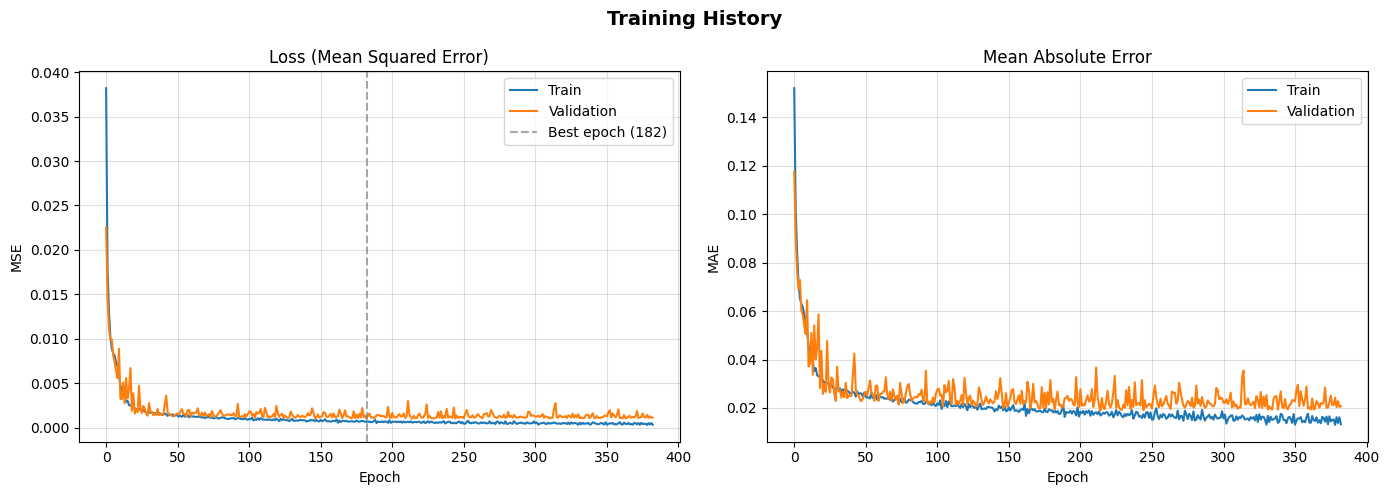

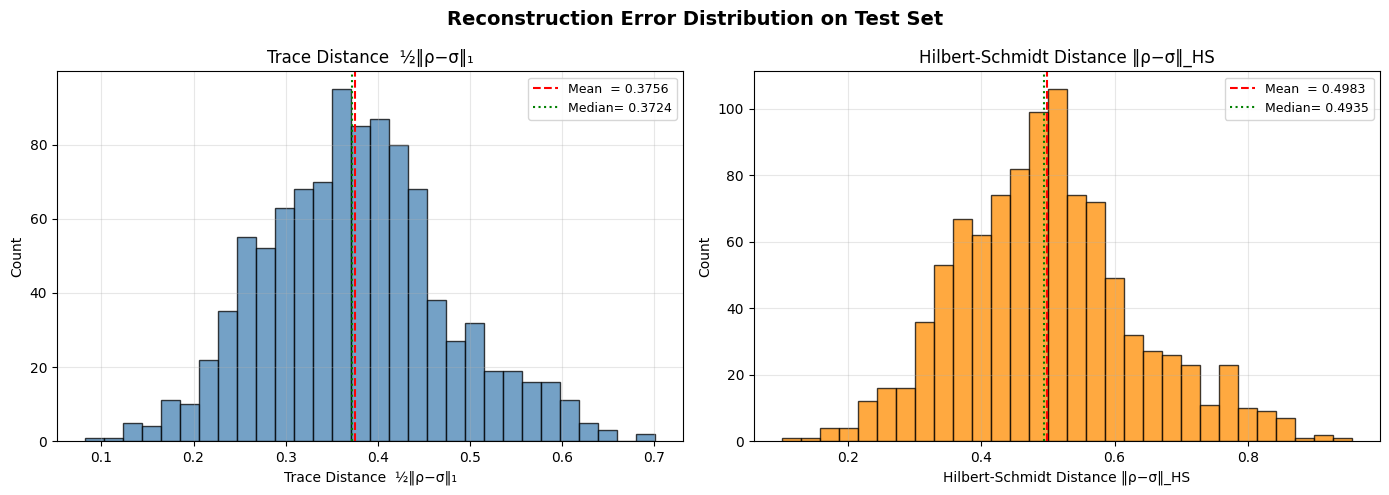

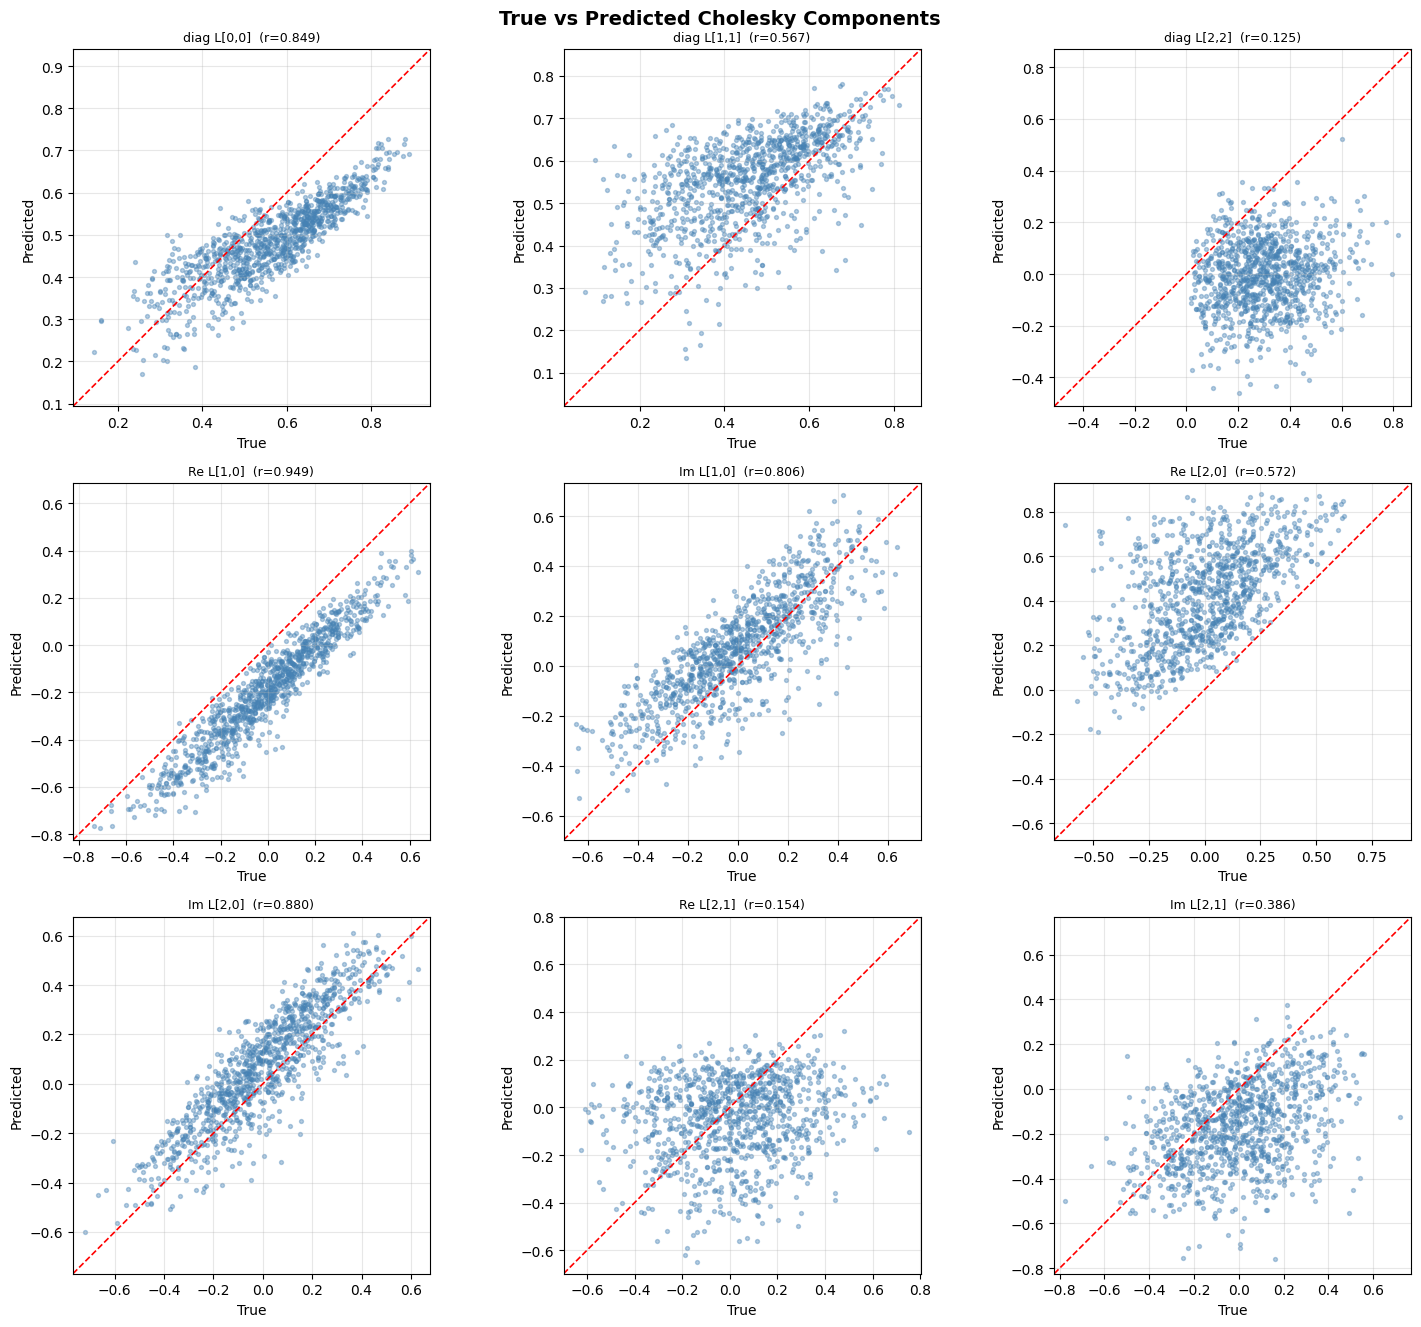

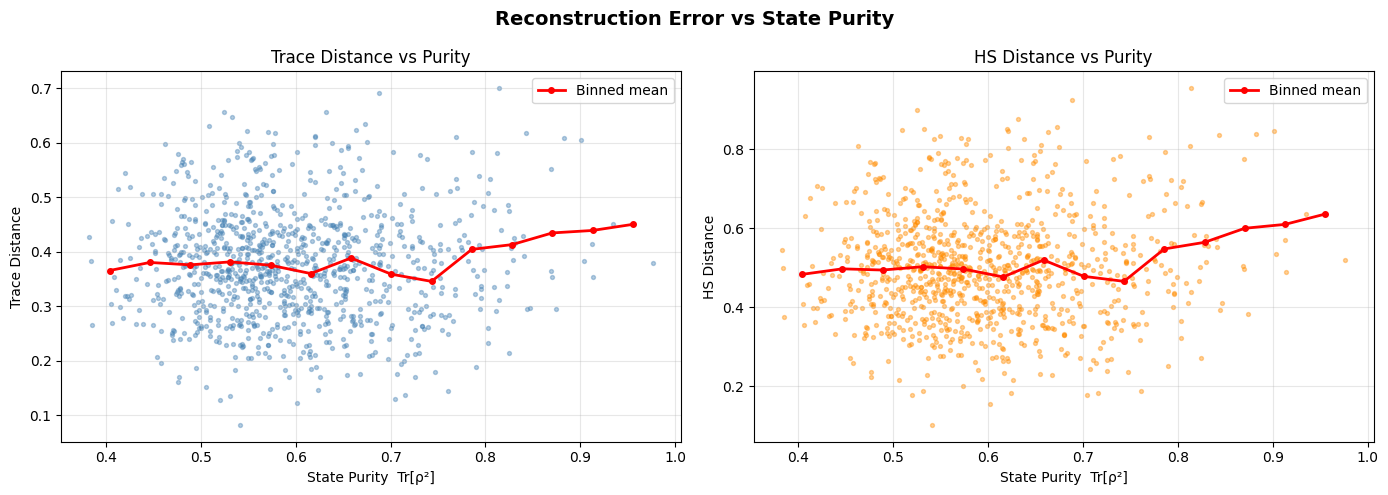

In [12]:
Y_pred = model.predict(X_test_worst)

import numpy as np
import matplotlib.pyplot as plt

# ── 0. Reconstruct density matrices from predicted Cholesky vectors ──────────

def cholesky_to_dm(vec, d):
    """
    Convert a Cholesky vector of length d^2 to a density matrix.
    vec layout:  d real diagonals, then for each i>j: (real, imag) of L[i,j]
    Returns a d×d complex array with trace 1.
    """
    T = np.zeros((d, d), dtype=complex)
    idx = 0
    for i in range(d):
        T[i, i] = vec[idx]
        idx += 1
    for i in range(d):
        for j in range(i):
            T[i, j] = vec[idx] + 1j * vec[idx + 1]
            idx += 2
    rho = T @ T.conj().T          # ρ = T T†  (note: corrected order vs original)
    trace = np.trace(rho).real
    if trace < 1e-12:             # guard against near-zero trace
        return np.eye(d, dtype=complex) / d
    return rho / trace


def trace_distance(rho, sigma):
    """Trace distance  ½ ‖ρ − σ‖₁  between two density matrices."""
    diff = rho - sigma
    return 0.5 * np.linalg.norm(diff, ord='nuc')


def hilbert_schmidt_distance(rho, sigma):
    """Hilbert-Schmidt distance  ‖ρ − σ‖_HS  (Frobenius norm of difference)."""
    diff = rho - sigma
    return np.sqrt(np.real(np.trace(diff @ diff)))


# ── Compute per-sample errors ─────────────────────────────────────────────────

trace_distances = []
hs_distances    = []

for true_vec, pred_vec in zip(Y_test, Y_pred):
    rho_true = cholesky_to_dm(true_vec, d)
    rho_pred = cholesky_to_dm(pred_vec, d)
    trace_distances.append(trace_distance(rho_true, rho_pred))
    hs_distances.append(hilbert_schmidt_distance(rho_true, rho_pred))

trace_distances = np.array(trace_distances)
hs_distances    = np.array(hs_distances)

print(f"Trace distance  –  mean: {trace_distances.mean():.4f}   "
      f"std: {trace_distances.std():.4f}   "
      f"max: {trace_distances.max():.4f}")
print(f"HS distance     –  mean: {hs_distances.mean():.4f}   "
      f"std: {hs_distances.std():.4f}   "
      f"max: {hs_distances.max():.4f}")


# ═══════════════════════════════════════════════════════════════════════════════
# FIGURE 1 – Training curves  (Loss + MAE)
# ═══════════════════════════════════════════════════════════════════════════════

hist = history.history
print("Metrics recorded:", list(hist.keys()))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Training History", fontsize=14, fontweight='bold')

# Left: MSE loss
ax = axes[0]
ax.plot(hist['loss'],     label='Train',      linewidth=1.5)
ax.plot(hist['val_loss'], label='Validation', linewidth=1.5)
if 'mae' in hist:                             # mark early-stop point
    best_epoch = int(np.argmin(hist['val_loss']))
    ax.axvline(best_epoch, color='grey', linestyle='--', alpha=0.7,
               label=f'Best epoch ({best_epoch})')
ax.set_title('Loss (Mean Squared Error)')
ax.set_xlabel('Epoch')
ax.set_ylabel('MSE')
ax.legend()
ax.grid(True, alpha=0.4)

# Right: MAE
ax = axes[1]
# handle both 'mae' and 'mean_absolute_error' key names
mae_key     = 'mae'     if 'mae'     in hist else 'mean_absolute_error'
val_mae_key = 'val_mae' if 'val_mae' in hist else 'val_mean_absolute_error'
ax.plot(hist[mae_key],     label='Train',      linewidth=1.5)
ax.plot(hist[val_mae_key], label='Validation', linewidth=1.5)
ax.set_title('Mean Absolute Error')
ax.set_xlabel('Epoch')
ax.set_ylabel('MAE')
ax.legend()
ax.grid(True, alpha=0.4)

plt.tight_layout()
plt.savefig('fig1_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()


# ═══════════════════════════════════════════════════════════════════════════════
# FIGURE 2 – Error distribution  (Trace distance + HS distance histograms)
# ═══════════════════════════════════════════════════════════════════════════════

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Reconstruction Error Distribution on Test Set",
             fontsize=14, fontweight='bold')

for ax, errors, label, color in zip(
        axes,
        [trace_distances, hs_distances],
        ['Trace Distance  ½‖ρ−σ‖₁', 'Hilbert-Schmidt Distance ‖ρ−σ‖_HS'],
        ['steelblue', 'darkorange']):

    ax.hist(errors, bins=30, color=color, edgecolor='black', alpha=0.75)
    ax.axvline(errors.mean(), color='red',    linestyle='--',
               linewidth=1.5, label=f'Mean  = {errors.mean():.4f}')
    ax.axvline(np.median(errors), color='green', linestyle=':',
               linewidth=1.5, label=f'Median= {np.median(errors):.4f}')
    ax.set_xlabel(label)
    ax.set_ylabel('Count')
    ax.set_title(label)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('fig2_error_distributions.png', dpi=150, bbox_inches='tight')
plt.show()


# ═══════════════════════════════════════════════════════════════════════════════
# FIGURE 3 – True vs Predicted scatter for every Cholesky component
# ═══════════════════════════════════════════════════════════════════════════════

n_components = Y_test.shape[1]          # d^2 = 9 for d=3
n_cols       = 3
n_rows       = int(np.ceil(n_components / n_cols))

# Build human-readable component labels
labels = []
for i in range(d):
    labels.append(f'diag L[{i},{i}]')
for i in range(d):
    for j in range(i):
        labels.append(f'Re L[{i},{j}]')
        labels.append(f'Im L[{i},{j}]')

fig, axes = plt.subplots(n_rows, n_cols,
                         figsize=(5 * n_cols, 4.5 * n_rows),
                         squeeze=False)
fig.suptitle("True vs Predicted Cholesky Components", fontsize=14,
             fontweight='bold')

for comp in range(n_components):
    row, col = divmod(comp, n_cols)
    ax = axes[row][col]

    true_vals = Y_test[:, comp]
    pred_vals = Y_pred[:, comp]

    ax.scatter(true_vals, pred_vals, alpha=0.4, s=8, color='steelblue')

    # Perfect-prediction reference line
    vmin = min(true_vals.min(), pred_vals.min()) - 0.05
    vmax = max(true_vals.max(), pred_vals.max()) + 0.05
    ax.plot([vmin, vmax], [vmin, vmax], 'r--', linewidth=1.2)

    # Pearson correlation
    corr = np.corrcoef(true_vals, pred_vals)[0, 1]
    ax.set_title(f'{labels[comp]}  (r={corr:.3f})', fontsize=9)
    ax.set_xlabel('True')
    ax.set_ylabel('Predicted')
    ax.set_xlim(vmin, vmax)
    ax.set_ylim(vmin, vmax)
    ax.set_aspect('equal', 'box')
    ax.grid(True, alpha=0.3)

# Hide any unused subplots
for comp in range(n_components, n_rows * n_cols):
    row, col = divmod(comp, n_cols)
    axes[row][col].set_visible(False)

plt.tight_layout()
plt.savefig('fig3_component_scatter.png', dpi=150, bbox_inches='tight')
plt.show()


# ═══════════════════════════════════════════════════════════════════════════════
# FIGURE 4 – Error vs true state purity
# (pure states near boundary are harder – matches Fig 4 discussion in paper)
# ═══════════════════════════════════════════════════════════════════════════════

purities = []
for true_vec in Y_test:
    rho = cholesky_to_dm(true_vec, d)
    purities.append(np.real(np.trace(rho @ rho)))

purities = np.array(purities)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Reconstruction Error vs State Purity", fontsize=14,
             fontweight='bold')

for ax, errors, label, color in zip(
        axes,
        [trace_distances, hs_distances],
        ['Trace Distance', 'HS Distance'],
        ['steelblue', 'darkorange']):

    ax.scatter(purities, errors, alpha=0.4, s=8, color=color)

    # Binned mean trend line
    bins      = np.linspace(purities.min(), purities.max(), 15)
    bin_idx   = np.digitize(purities, bins)
    bin_means = [errors[bin_idx == k].mean()
                 for k in range(1, len(bins))
                 if (bin_idx == k).sum() > 0]
    bin_centers = [(bins[k] + bins[k + 1]) / 2
                   for k in range(len(bins) - 1)
                   if (bin_idx == k + 1).sum() > 0]
    ax.plot(bin_centers, bin_means, 'r-o', linewidth=2,
            markersize=4, label='Binned mean')

    ax.set_xlabel('State Purity  Tr[ρ²]')
    ax.set_ylabel(label)
    ax.set_title(f'{label} vs Purity')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('fig4_error_vs_purity.png', dpi=150, bbox_inches='tight')
plt.show()

**Random**

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Trace distance  –  mean: 0.0793   std: 0.0291   max: 0.2105
HS distance     –  mean: 0.1044   std: 0.0378   max: 0.2737
Metrics recorded: ['loss', 'mae', 'val_loss', 'val_mae']


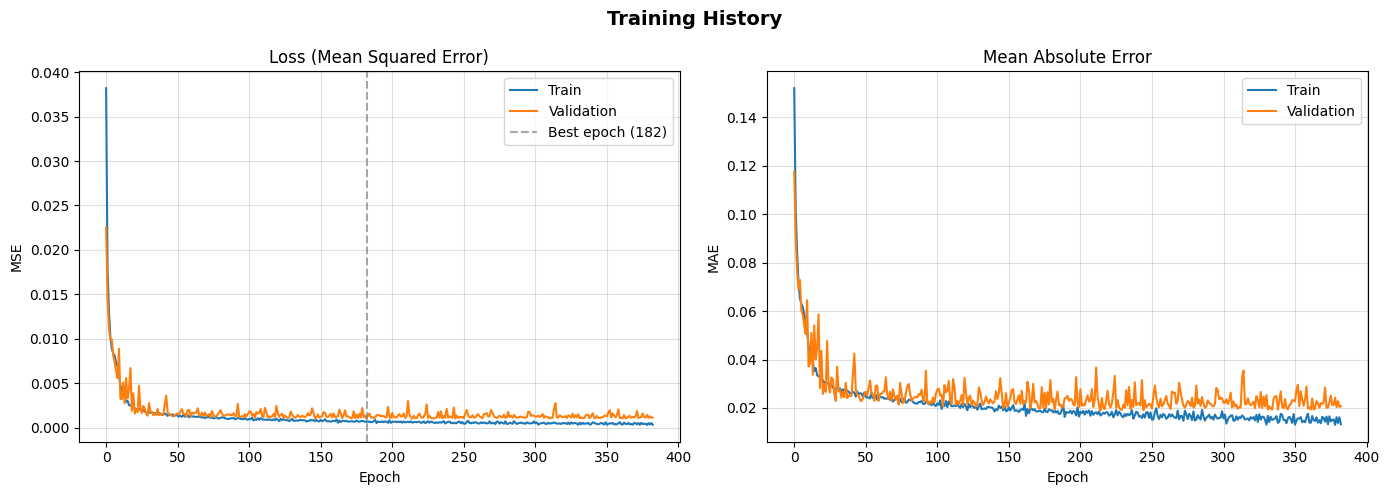

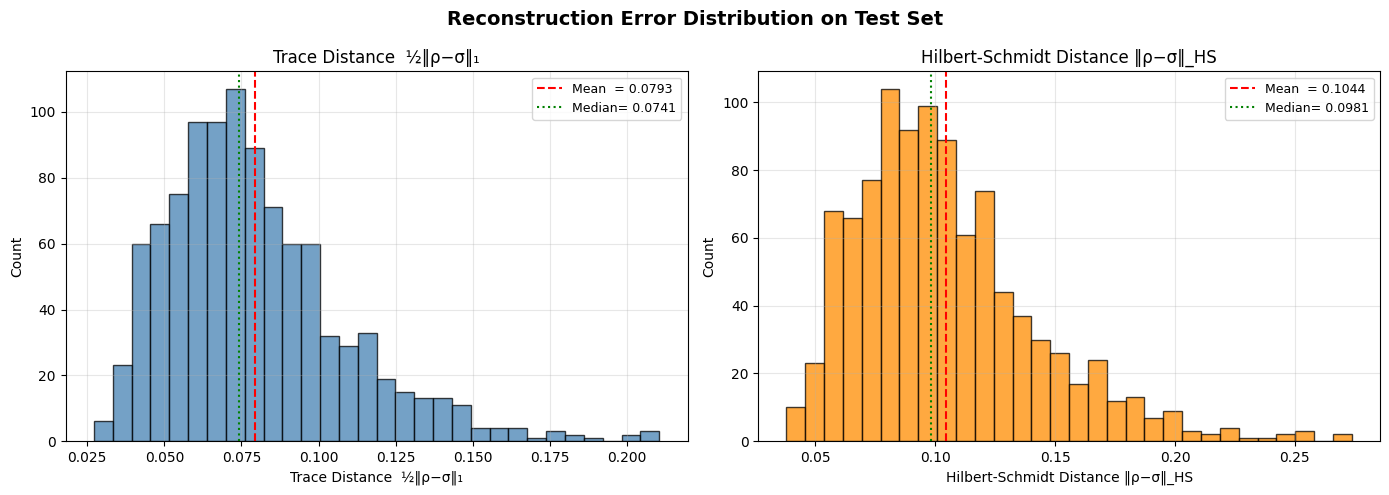

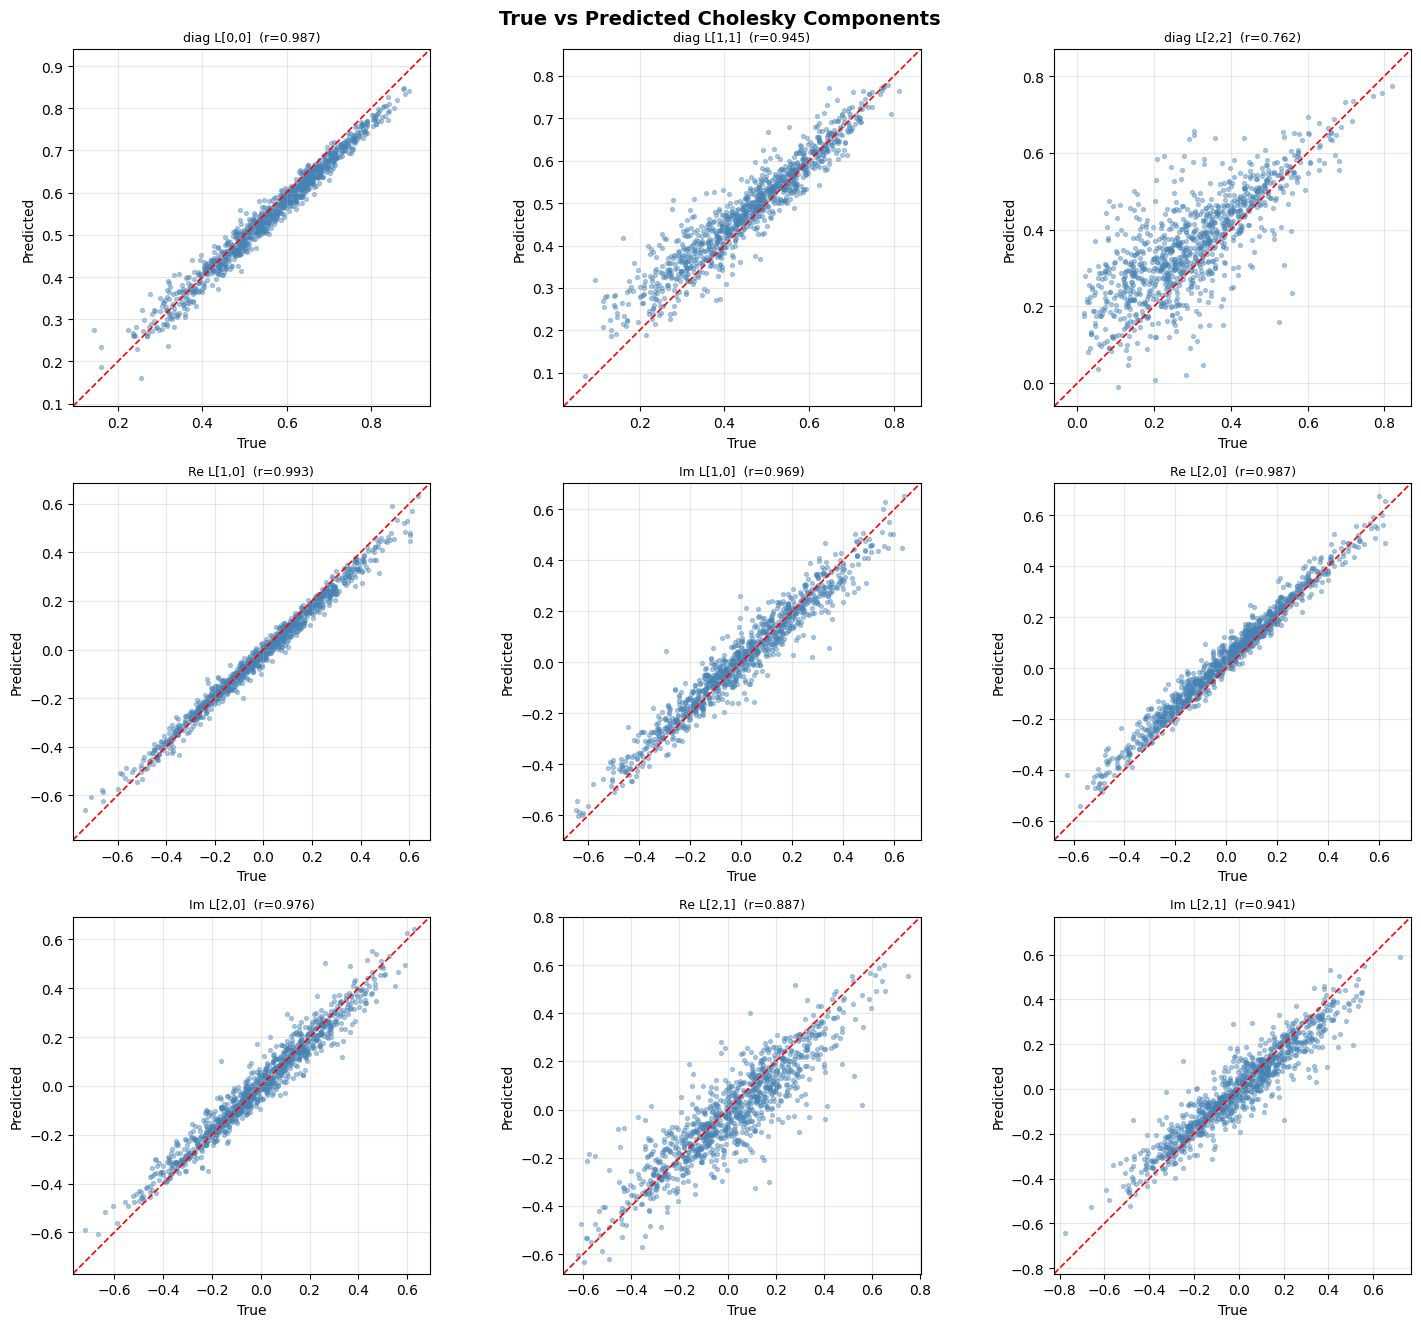

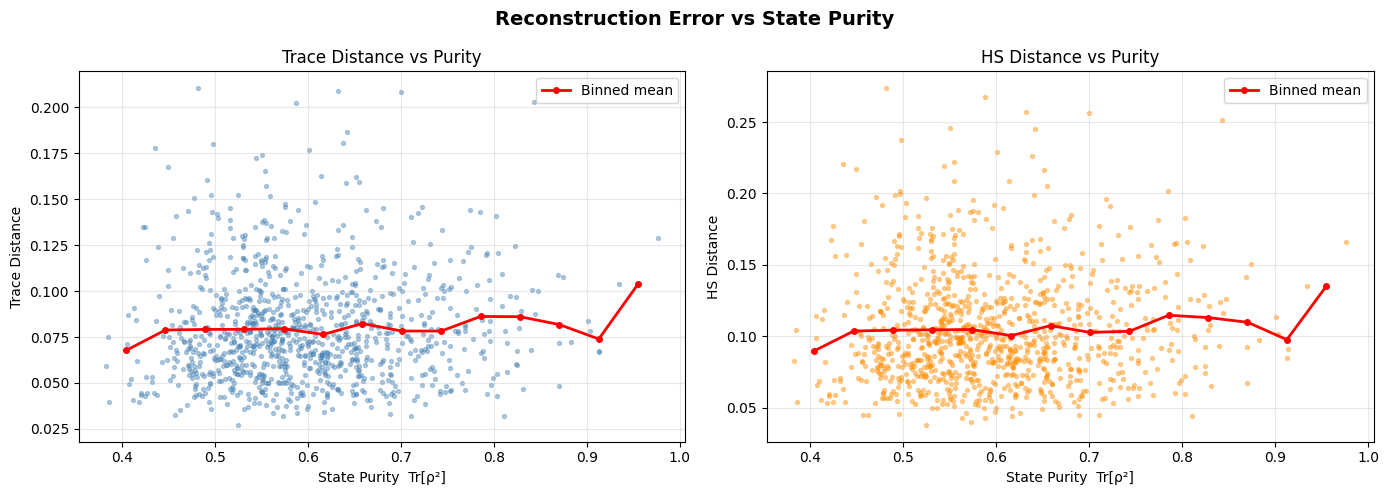

In [13]:
Y_pred = model.predict(X_test_random)

import numpy as np
import matplotlib.pyplot as plt

# ── 0. Reconstruct density matrices from predicted Cholesky vectors ──────────

def cholesky_to_dm(vec, d):
    """
    Convert a Cholesky vector of length d^2 to a density matrix.
    vec layout:  d real diagonals, then for each i>j: (real, imag) of L[i,j]
    Returns a d×d complex array with trace 1.
    """
    T = np.zeros((d, d), dtype=complex)
    idx = 0
    for i in range(d):
        T[i, i] = vec[idx]
        idx += 1
    for i in range(d):
        for j in range(i):
            T[i, j] = vec[idx] + 1j * vec[idx + 1]
            idx += 2
    rho = T @ T.conj().T          # ρ = T T†  (note: corrected order vs original)
    trace = np.trace(rho).real
    if trace < 1e-12:             # guard against near-zero trace
        return np.eye(d, dtype=complex) / d
    return rho / trace


def trace_distance(rho, sigma):
    """Trace distance  ½ ‖ρ − σ‖₁  between two density matrices."""
    diff = rho - sigma
    return 0.5 * np.linalg.norm(diff, ord='nuc')


def hilbert_schmidt_distance(rho, sigma):
    """Hilbert-Schmidt distance  ‖ρ − σ‖_HS  (Frobenius norm of difference)."""
    diff = rho - sigma
    return np.sqrt(np.real(np.trace(diff @ diff)))


# ── Compute per-sample errors ─────────────────────────────────────────────────

trace_distances = []
hs_distances    = []

for true_vec, pred_vec in zip(Y_test, Y_pred):
    rho_true = cholesky_to_dm(true_vec, d)
    rho_pred = cholesky_to_dm(pred_vec, d)
    trace_distances.append(trace_distance(rho_true, rho_pred))
    hs_distances.append(hilbert_schmidt_distance(rho_true, rho_pred))

trace_distances = np.array(trace_distances)
hs_distances    = np.array(hs_distances)

print(f"Trace distance  –  mean: {trace_distances.mean():.4f}   "
      f"std: {trace_distances.std():.4f}   "
      f"max: {trace_distances.max():.4f}")
print(f"HS distance     –  mean: {hs_distances.mean():.4f}   "
      f"std: {hs_distances.std():.4f}   "
      f"max: {hs_distances.max():.4f}")


# ═══════════════════════════════════════════════════════════════════════════════
# FIGURE 1 – Training curves  (Loss + MAE)
# ═══════════════════════════════════════════════════════════════════════════════

hist = history.history
print("Metrics recorded:", list(hist.keys()))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Training History", fontsize=14, fontweight='bold')

# Left: MSE loss
ax = axes[0]
ax.plot(hist['loss'],     label='Train',      linewidth=1.5)
ax.plot(hist['val_loss'], label='Validation', linewidth=1.5)
if 'mae' in hist:                             # mark early-stop point
    best_epoch = int(np.argmin(hist['val_loss']))
    ax.axvline(best_epoch, color='grey', linestyle='--', alpha=0.7,
               label=f'Best epoch ({best_epoch})')
ax.set_title('Loss (Mean Squared Error)')
ax.set_xlabel('Epoch')
ax.set_ylabel('MSE')
ax.legend()
ax.grid(True, alpha=0.4)

# Right: MAE
ax = axes[1]
# handle both 'mae' and 'mean_absolute_error' key names
mae_key     = 'mae'     if 'mae'     in hist else 'mean_absolute_error'
val_mae_key = 'val_mae' if 'val_mae' in hist else 'val_mean_absolute_error'
ax.plot(hist[mae_key],     label='Train',      linewidth=1.5)
ax.plot(hist[val_mae_key], label='Validation', linewidth=1.5)
ax.set_title('Mean Absolute Error')
ax.set_xlabel('Epoch')
ax.set_ylabel('MAE')
ax.legend()
ax.grid(True, alpha=0.4)

plt.tight_layout()
plt.savefig('fig1_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()


# ═══════════════════════════════════════════════════════════════════════════════
# FIGURE 2 – Error distribution  (Trace distance + HS distance histograms)
# ═══════════════════════════════════════════════════════════════════════════════

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Reconstruction Error Distribution on Test Set",
             fontsize=14, fontweight='bold')

for ax, errors, label, color in zip(
        axes,
        [trace_distances, hs_distances],
        ['Trace Distance  ½‖ρ−σ‖₁', 'Hilbert-Schmidt Distance ‖ρ−σ‖_HS'],
        ['steelblue', 'darkorange']):

    ax.hist(errors, bins=30, color=color, edgecolor='black', alpha=0.75)
    ax.axvline(errors.mean(), color='red',    linestyle='--',
               linewidth=1.5, label=f'Mean  = {errors.mean():.4f}')
    ax.axvline(np.median(errors), color='green', linestyle=':',
               linewidth=1.5, label=f'Median= {np.median(errors):.4f}')
    ax.set_xlabel(label)
    ax.set_ylabel('Count')
    ax.set_title(label)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('fig2_error_distributions.png', dpi=150, bbox_inches='tight')
plt.show()


# ═══════════════════════════════════════════════════════════════════════════════
# FIGURE 3 – True vs Predicted scatter for every Cholesky component
# ═══════════════════════════════════════════════════════════════════════════════

n_components = Y_test.shape[1]          # d^2 = 9 for d=3
n_cols       = 3
n_rows       = int(np.ceil(n_components / n_cols))

# Build human-readable component labels
labels = []
for i in range(d):
    labels.append(f'diag L[{i},{i}]')
for i in range(d):
    for j in range(i):
        labels.append(f'Re L[{i},{j}]')
        labels.append(f'Im L[{i},{j}]')

fig, axes = plt.subplots(n_rows, n_cols,
                         figsize=(5 * n_cols, 4.5 * n_rows),
                         squeeze=False)
fig.suptitle("True vs Predicted Cholesky Components", fontsize=14,
             fontweight='bold')

for comp in range(n_components):
    row, col = divmod(comp, n_cols)
    ax = axes[row][col]

    true_vals = Y_test[:, comp]
    pred_vals = Y_pred[:, comp]

    ax.scatter(true_vals, pred_vals, alpha=0.4, s=8, color='steelblue')

    # Perfect-prediction reference line
    vmin = min(true_vals.min(), pred_vals.min()) - 0.05
    vmax = max(true_vals.max(), pred_vals.max()) + 0.05
    ax.plot([vmin, vmax], [vmin, vmax], 'r--', linewidth=1.2)

    # Pearson correlation
    corr = np.corrcoef(true_vals, pred_vals)[0, 1]
    ax.set_title(f'{labels[comp]}  (r={corr:.3f})', fontsize=9)
    ax.set_xlabel('True')
    ax.set_ylabel('Predicted')
    ax.set_xlim(vmin, vmax)
    ax.set_ylim(vmin, vmax)
    ax.set_aspect('equal', 'box')
    ax.grid(True, alpha=0.3)

# Hide any unused subplots
for comp in range(n_components, n_rows * n_cols):
    row, col = divmod(comp, n_cols)
    axes[row][col].set_visible(False)

plt.tight_layout()
plt.savefig('fig3_component_scatter.png', dpi=150, bbox_inches='tight')
plt.show()


# ═══════════════════════════════════════════════════════════════════════════════
# FIGURE 4 – Error vs true state purity
# (pure states near boundary are harder – matches Fig 4 discussion in paper)
# ═══════════════════════════════════════════════════════════════════════════════

purities = []
for true_vec in Y_test:
    rho = cholesky_to_dm(true_vec, d)
    purities.append(np.real(np.trace(rho @ rho)))

purities = np.array(purities)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Reconstruction Error vs State Purity", fontsize=14,
             fontweight='bold')

for ax, errors, label, color in zip(
        axes,
        [trace_distances, hs_distances],
        ['Trace Distance', 'HS Distance'],
        ['steelblue', 'darkorange']):

    ax.scatter(purities, errors, alpha=0.4, s=8, color=color)

    # Binned mean trend line
    bins      = np.linspace(purities.min(), purities.max(), 15)
    bin_idx   = np.digitize(purities, bins)
    bin_means = [errors[bin_idx == k].mean()
                 for k in range(1, len(bins))
                 if (bin_idx == k).sum() > 0]
    bin_centers = [(bins[k] + bins[k + 1]) / 2
                   for k in range(len(bins) - 1)
                   if (bin_idx == k + 1).sum() > 0]
    ax.plot(bin_centers, bin_means, 'r-o', linewidth=2,
            markersize=4, label='Binned mean')

    ax.set_xlabel('State Purity  Tr[ρ²]')
    ax.set_ylabel(label)
    ax.set_title(f'{label} vs Purity')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('fig4_error_vs_purity.png', dpi=150, bbox_inches='tight')
plt.show()

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Trace distance  –  mean: 0.4506   std: 0.1146   max: 0.7816
HS distance     –  mean: 0.5961   std: 0.1528   max: 1.0213
Metrics recorded: ['loss', 'mae', 'val_loss', 'val_mae']


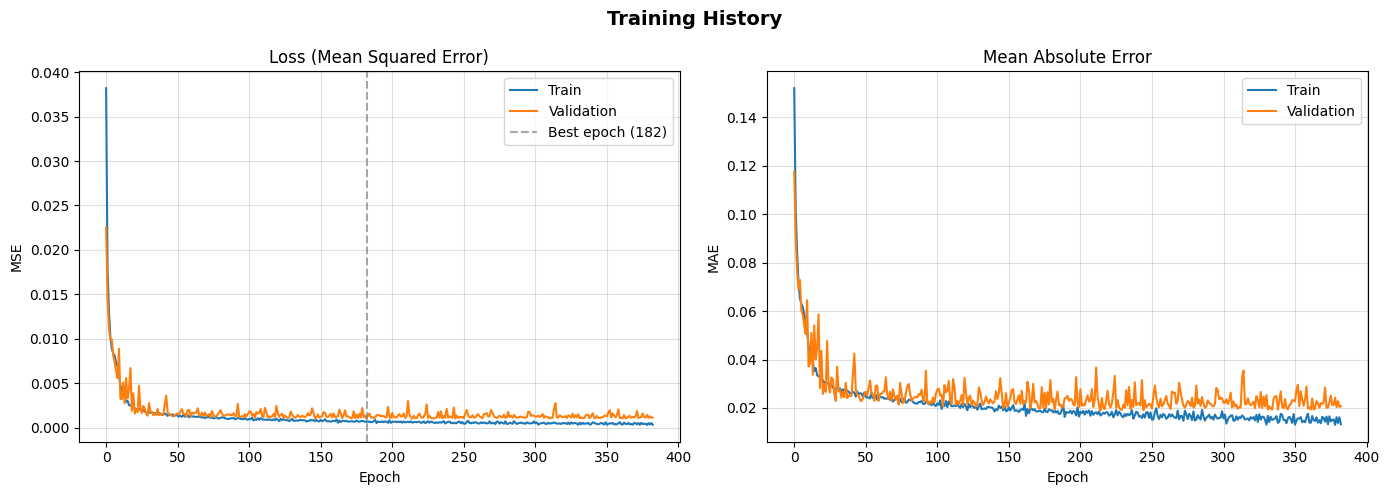

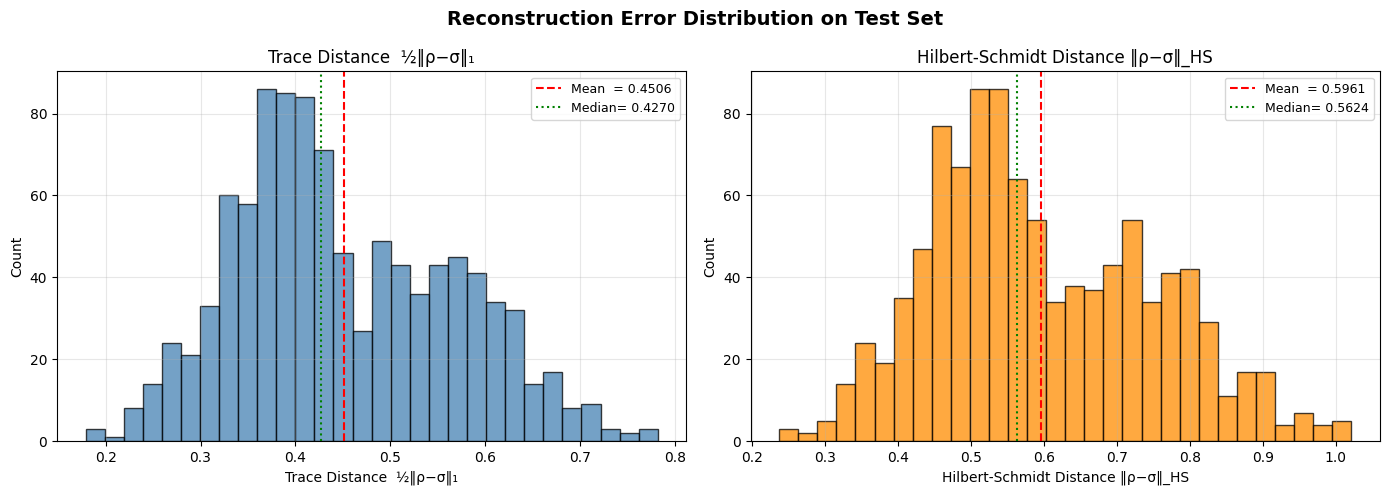

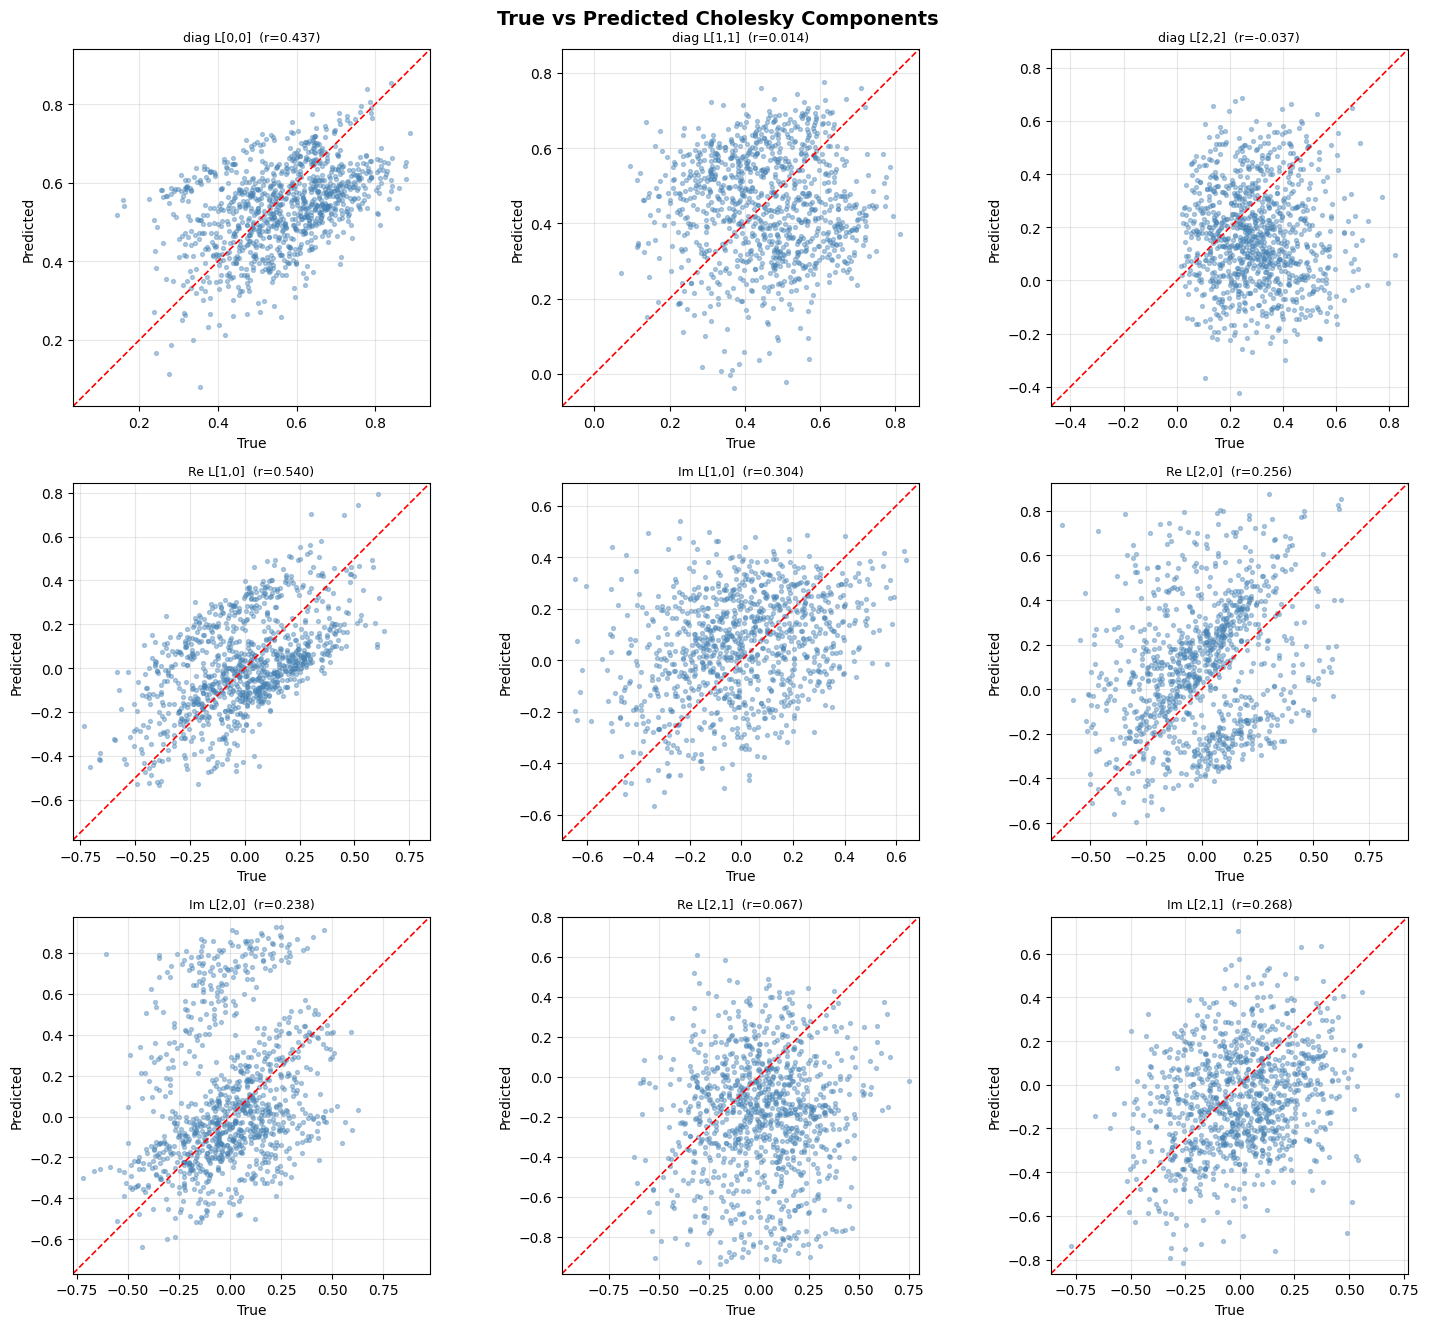

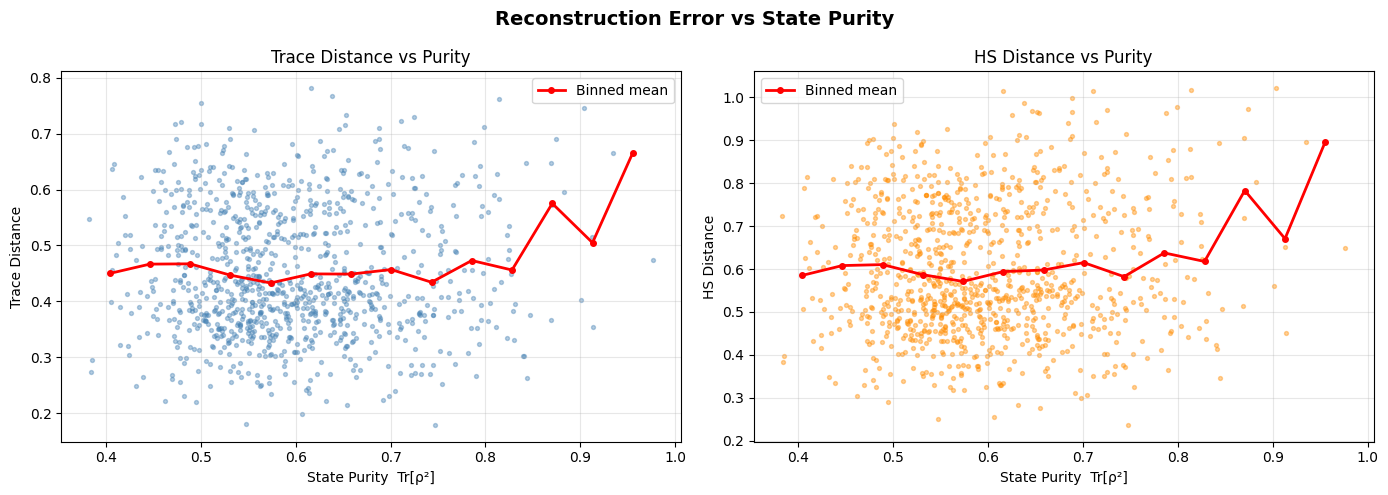

In [14]:
Y_pred = model.predict(X_test_targeted)

import numpy as np
import matplotlib.pyplot as plt

# ── 0. Reconstruct density matrices from predicted Cholesky vectors ──────────

def cholesky_to_dm(vec, d):
    """
    Convert a Cholesky vector of length d^2 to a density matrix.
    vec layout:  d real diagonals, then for each i>j: (real, imag) of L[i,j]
    Returns a d×d complex array with trace 1.
    """
    T = np.zeros((d, d), dtype=complex)
    idx = 0
    for i in range(d):
        T[i, i] = vec[idx]
        idx += 1
    for i in range(d):
        for j in range(i):
            T[i, j] = vec[idx] + 1j * vec[idx + 1]
            idx += 2
    rho = T @ T.conj().T          # ρ = T T†  (note: corrected order vs original)
    trace = np.trace(rho).real
    if trace < 1e-12:             # guard against near-zero trace
        return np.eye(d, dtype=complex) / d
    return rho / trace


def trace_distance(rho, sigma):
    """Trace distance  ½ ‖ρ − σ‖₁  between two density matrices."""
    diff = rho - sigma
    return 0.5 * np.linalg.norm(diff, ord='nuc')


def hilbert_schmidt_distance(rho, sigma):
    """Hilbert-Schmidt distance  ‖ρ − σ‖_HS  (Frobenius norm of difference)."""
    diff = rho - sigma
    return np.sqrt(np.real(np.trace(diff @ diff)))


# ── Compute per-sample errors ─────────────────────────────────────────────────

trace_distances = []
hs_distances    = []

for true_vec, pred_vec in zip(Y_test, Y_pred):
    rho_true = cholesky_to_dm(true_vec, d)
    rho_pred = cholesky_to_dm(pred_vec, d)
    trace_distances.append(trace_distance(rho_true, rho_pred))
    hs_distances.append(hilbert_schmidt_distance(rho_true, rho_pred))

trace_distances = np.array(trace_distances)
hs_distances    = np.array(hs_distances)

print(f"Trace distance  –  mean: {trace_distances.mean():.4f}   "
      f"std: {trace_distances.std():.4f}   "
      f"max: {trace_distances.max():.4f}")
print(f"HS distance     –  mean: {hs_distances.mean():.4f}   "
      f"std: {hs_distances.std():.4f}   "
      f"max: {hs_distances.max():.4f}")


# ═══════════════════════════════════════════════════════════════════════════════
# FIGURE 1 – Training curves  (Loss + MAE)
# ═══════════════════════════════════════════════════════════════════════════════

hist = history.history
print("Metrics recorded:", list(hist.keys()))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Training History", fontsize=14, fontweight='bold')

# Left: MSE loss
ax = axes[0]
ax.plot(hist['loss'],     label='Train',      linewidth=1.5)
ax.plot(hist['val_loss'], label='Validation', linewidth=1.5)
if 'mae' in hist:                             # mark early-stop point
    best_epoch = int(np.argmin(hist['val_loss']))
    ax.axvline(best_epoch, color='grey', linestyle='--', alpha=0.7,
               label=f'Best epoch ({best_epoch})')
ax.set_title('Loss (Mean Squared Error)')
ax.set_xlabel('Epoch')
ax.set_ylabel('MSE')
ax.legend()
ax.grid(True, alpha=0.4)

# Right: MAE
ax = axes[1]
# handle both 'mae' and 'mean_absolute_error' key names
mae_key     = 'mae'     if 'mae'     in hist else 'mean_absolute_error'
val_mae_key = 'val_mae' if 'val_mae' in hist else 'val_mean_absolute_error'
ax.plot(hist[mae_key],     label='Train',      linewidth=1.5)
ax.plot(hist[val_mae_key], label='Validation', linewidth=1.5)
ax.set_title('Mean Absolute Error')
ax.set_xlabel('Epoch')
ax.set_ylabel('MAE')
ax.legend()
ax.grid(True, alpha=0.4)

plt.tight_layout()
plt.savefig('fig1_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()


# ═══════════════════════════════════════════════════════════════════════════════
# FIGURE 2 – Error distribution  (Trace distance + HS distance histograms)
# ═══════════════════════════════════════════════════════════════════════════════

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Reconstruction Error Distribution on Test Set",
             fontsize=14, fontweight='bold')

for ax, errors, label, color in zip(
        axes,
        [trace_distances, hs_distances],
        ['Trace Distance  ½‖ρ−σ‖₁', 'Hilbert-Schmidt Distance ‖ρ−σ‖_HS'],
        ['steelblue', 'darkorange']):

    ax.hist(errors, bins=30, color=color, edgecolor='black', alpha=0.75)
    ax.axvline(errors.mean(), color='red',    linestyle='--',
               linewidth=1.5, label=f'Mean  = {errors.mean():.4f}')
    ax.axvline(np.median(errors), color='green', linestyle=':',
               linewidth=1.5, label=f'Median= {np.median(errors):.4f}')
    ax.set_xlabel(label)
    ax.set_ylabel('Count')
    ax.set_title(label)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('fig2_error_distributions.png', dpi=150, bbox_inches='tight')
plt.show()


# ═══════════════════════════════════════════════════════════════════════════════
# FIGURE 3 – True vs Predicted scatter for every Cholesky component
# ═══════════════════════════════════════════════════════════════════════════════

n_components = Y_test.shape[1]          # d^2 = 9 for d=3
n_cols       = 3
n_rows       = int(np.ceil(n_components / n_cols))

# Build human-readable component labels
labels = []
for i in range(d):
    labels.append(f'diag L[{i},{i}]')
for i in range(d):
    for j in range(i):
        labels.append(f'Re L[{i},{j}]')
        labels.append(f'Im L[{i},{j}]')

fig, axes = plt.subplots(n_rows, n_cols,
                         figsize=(5 * n_cols, 4.5 * n_rows),
                         squeeze=False)
fig.suptitle("True vs Predicted Cholesky Components", fontsize=14,
             fontweight='bold')

for comp in range(n_components):
    row, col = divmod(comp, n_cols)
    ax = axes[row][col]

    true_vals = Y_test[:, comp]
    pred_vals = Y_pred[:, comp]

    ax.scatter(true_vals, pred_vals, alpha=0.4, s=8, color='steelblue')

    # Perfect-prediction reference line
    vmin = min(true_vals.min(), pred_vals.min()) - 0.05
    vmax = max(true_vals.max(), pred_vals.max()) + 0.05
    ax.plot([vmin, vmax], [vmin, vmax], 'r--', linewidth=1.2)

    # Pearson correlation
    corr = np.corrcoef(true_vals, pred_vals)[0, 1]
    ax.set_title(f'{labels[comp]}  (r={corr:.3f})', fontsize=9)
    ax.set_xlabel('True')
    ax.set_ylabel('Predicted')
    ax.set_xlim(vmin, vmax)
    ax.set_ylim(vmin, vmax)
    ax.set_aspect('equal', 'box')
    ax.grid(True, alpha=0.3)

# Hide any unused subplots
for comp in range(n_components, n_rows * n_cols):
    row, col = divmod(comp, n_cols)
    axes[row][col].set_visible(False)

plt.tight_layout()
plt.savefig('fig3_component_scatter.png', dpi=150, bbox_inches='tight')
plt.show()


# ═══════════════════════════════════════════════════════════════════════════════
# FIGURE 4 – Error vs true state purity
# (pure states near boundary are harder – matches Fig 4 discussion in paper)
# ═══════════════════════════════════════════════════════════════════════════════

purities = []
for true_vec in Y_test:
    rho = cholesky_to_dm(true_vec, d)
    purities.append(np.real(np.trace(rho @ rho)))

purities = np.array(purities)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Reconstruction Error vs State Purity", fontsize=14,
             fontweight='bold')

for ax, errors, label, color in zip(
        axes,
        [trace_distances, hs_distances],
        ['Trace Distance', 'HS Distance'],
        ['steelblue', 'darkorange']):

    ax.scatter(purities, errors, alpha=0.4, s=8, color=color)

    # Binned mean trend line
    bins      = np.linspace(purities.min(), purities.max(), 15)
    bin_idx   = np.digitize(purities, bins)
    bin_means = [errors[bin_idx == k].mean()
                 for k in range(1, len(bins))
                 if (bin_idx == k).sum() > 0]
    bin_centers = [(bins[k] + bins[k + 1]) / 2
                   for k in range(len(bins) - 1)
                   if (bin_idx == k + 1).sum() > 0]
    ax.plot(bin_centers, bin_means, 'r-o', linewidth=2,
            markersize=4, label='Binned mean')

    ax.set_xlabel('State Purity  Tr[ρ²]')
    ax.set_ylabel(label)
    ax.set_title(f'{label} vs Purity')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('fig4_error_vs_purity.png', dpi=150, bbox_inches='tight')
plt.show()

**D = 7**

**Data Set Generation**

In [1]:
!pip install qutip

import numpy as np
import qutip as qt
from scipy.stats import multinomial
import os

# ----------------------------------------------------------------------
# Step 1 & 2: Set dimension and POVM size
# ----------------------------------------------------------------------
d = 3                     # dimension of the Hilbert space
N = d**2                  # number of POVM outcomes (informationally complete)
# For better performance you could use N = 2*d**2, but keep it simple here

# ----------------------------------------------------------------------
# Step 3: Construct a rank‑1 POVM via the square‑root measurement
#         using Haar‑random pure states.
# ----------------------------------------------------------------------
def generate_square_root_povm(d, N):
    """
    Generate a POVM {Π_i} with N outcomes.
    The construction follows the square‑root (pretty good) measurement:
      1. Draw N Haar‑random pure states |ψ_i⟩.
      2. Compute the frame operator S = Σ_i |ψ_i⟩⟨ψ_i|.
      3. Define Π_i = S^{-1/2} |ψ_i⟩⟨ψ_i| S^{-1/2}.
    Then Σ_i Π_i = I.
    """
    # 1. Generate Haar random kets
    kets = [qt.rand_ket(d) for _ in range(N)]

    # 2. Frame operator S
    S = sum(ket * ket.dag() for ket in kets)

    # 3. Inverse square root of S via eigen decomposition
    evals, evecs = S.eigenstates()
    # S^{-1/2} = Σ_k (1/√(λ_k)) |e_k⟩⟨e_k|
    S_inv_sqrt = sum((1 / np.sqrt(evals[k])) * evecs[k] * evecs[k].dag() for k in range(d))

    # 4. Build each POVM element
    povm = []
    for ket in kets:
        proj = ket * ket.dag()
        Pi = S_inv_sqrt * proj * S_inv_sqrt
        povm.append(Pi)

    return povm

print(f"Generating POVM for d={d} with N={N} outcomes...")
povm_qobj = generate_square_root_povm(d, N)          # list of Qobj
povm_np = [Pi.full() for Pi in povm_qobj]            # as numpy arrays for faster trace

# ----------------------------------------------------------------------
# Step 4 & 6: Helper functions for probabilities and Cholesky labels
# ----------------------------------------------------------------------
def probabilities(rho, povm_np):
    """Return the vector p_ℓ = Tr(ρ Π_ℓ) for a given density matrix ρ."""
    rho_mat = rho.full()
    p = [np.trace(rho_mat @ Pi).real for Pi in povm_np]
    return np.array(p, dtype=np.float32)

def cholesky_vector(rho):
    """
    Convert a density matrix ρ into a flat vector of its Cholesky parameters.
    ρ = L L^†, with L lower triangular.
    The vector contains (in order):
      - the d real diagonal entries of L,
      - for each i>j: the real and imaginary parts of L[i,j].
    Total length = d^2.
    """
    rho_mat = rho.full()
    # Ensure ρ is numerically positive (add small epsilon if needed)
    eigvals = np.linalg.eigvalsh(rho_mat)
    if np.min(eigvals) < 0:
        rho_mat += (-np.min(eigvals) + 1e-12) * np.eye(d)
    L = np.linalg.cholesky(rho_mat)   # L is lower triangular, complex
    vec = []
    # diagonal (real)
    for i in range(d):
        vec.append(L[i,i].real)
    # off-diagonals i>j (complex)
    for i in range(d):
        for j in range(i):
            vec.append(L[i,j].real)
            vec.append(L[i,j].imag)
    return np.array(vec, dtype=np.float32)

# ----------------------------------------------------------------------
# Step 2 (cont.): Generate random density matrices from the Ginibre ensemble
# ----------------------------------------------------------------------
def random_density_matrix_ginibre(d):
    """Draw a random density matrix according to ρ = X X† / Tr(X X†),
       where X is a complex Ginibre matrix (i.i.d. normal entries)."""
    # Using QuTiP's built‑in method (distribution='ginibre' is the default)
    return qt.rand_dm(d, density=1, distribution='ginibre')

# ----------------------------------------------------------------------
# Step 5 & 7: Create the dataset (training + validation + test)
# ----------------------------------------------------------------------
# For demonstration we use modest sizes. In practice you would scale up.
total_train_val = 10_000      # total training+validation samples
train_frac = 0.8
val_frac = 0.2
n_train = int(total_train_val * train_frac)
n_val   = total_train_val - n_train
n_test  = 1_000                # separate test set

print(f"Generating {total_train_val} training/validation states and {n_test} test states...")

X_train, Y_train = [], []
X_val,   Y_val   = [], []

# Mix of ideal (75%) and sampled (25%) probabilities
for i in range(total_train_val):
    if i % 1000 == 0:
        print(f"  Progress: {i}/{total_train_val}")

    rho = random_density_matrix_ginibre(d)
    p_ideal = probabilities(rho, povm_np)

    # Decide whether to use ideal or sampled probabilities
    if np.random.rand() < 0.75:          # 75% ideal
        p = p_ideal
    else:                                 # 25% sampled with random number of trials
        T = np.random.randint(d**2, 100_001)
        counts = multinomial.rvs(n=T, p=p_ideal, size=1)[0]
        p = counts / T

    y = cholesky_vector(rho)

    # Assign to training or validation
    if i < n_train:
        X_train.append(p)
        Y_train.append(y)
    else:
        X_val.append(p)
        Y_val.append(y)

# Convert to numpy arrays
X_train = np.array(X_train)
Y_train = np.array(Y_train)
X_val   = np.array(X_val)
Y_val   = np.array(Y_val)

print(f"Training set:   {X_train.shape}")
print(f"Validation set: {X_val.shape}")

# ----------------------------------------------------------------------
# Generate the separate test set (using ideal probabilities for simplicity)
# ----------------------------------------------------------------------
X_test, Y_test = [], []
for i in range(n_test):
    if i % 200 == 0:
        print(f"  Test progress: {i}/{n_test}")
    rho = random_density_matrix_ginibre(d)
    p_ideal = probabilities(rho, povm_np)
    y = cholesky_vector(rho)
    X_test.append(p_ideal)
    Y_test.append(y)

X_test = np.array(X_test)
Y_test = np.array(Y_test)
print(f"Test set: {X_test.shape}")

# ----------------------------------------------------------------------
# (Optional) Save to disk
# ----------------------------------------------------------------------
save_dir = f"dataset_d{d}"
os.makedirs(save_dir, exist_ok=True)
np.save(os.path.join(save_dir, "X_train.npy"), X_train)
np.save(os.path.join(save_dir, "Y_train.npy"), Y_train)
np.save(os.path.join(save_dir, "X_val.npy"),   X_val)
np.save(os.path.join(save_dir, "Y_val.npy"),   Y_val)
np.save(os.path.join(save_dir, "X_test.npy"),  X_test)
np.save(os.path.join(save_dir, "Y_test.npy"),  Y_test)

print(f"Dataset for d={d} saved in '{save_dir}'.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 33.1/33.1 MB 50.6 MB/s eta 0:00:00:00:0100:01
Generating POVM for d=3 with N=9 outcomes...
Generating 10000 training/validation states and 1000 test states...
  Progress: 0/10000
  Progress: 1000/10000
  Progress: 2000/10000
  Progress: 3000/10000
  Progress: 4000/10000
  Progress: 5000/10000
  Progress: 6000/10000
  Progress: 7000/10000
  Progress: 8000/10000
  Progress: 9000/10000
Training set:   (8000, 9)
Validation set: (2000, 9)
  Test progress: 0/1000
  Test progress: 200/1000
  Test progress: 400/1000
  Test progress: 600/1000
  Test progress: 800/1000
Test set: (1000, 9)
Dataset for d=3 saved in 'dataset_d3'.
